<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">Supervivencia en Cáncer de Mama</p>
<p style="margin: 0; text-align:right;">2026-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
<p style="margin: 0; text-align:right;">Julio Úbeda Quesada</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# Análisis de Supervivencia y Predicción de Riesgo Clínico en Cáncer de Mama

**Notebook específico para el conjunto de datos TCGA-BRCA (`brca_tcga_gdc_clinical_data.tsv`).**

Este cuaderno replica la lógica del notebook de METABRIC y la adapta a la cohorte TCGA:
1. carga y descripción del dataset clínico;
2. EDA reutilizando el módulo `EDA_functions.py`;
3. limpieza orientada a supervivencia;
4. preprocesamiento reproducible para Kaplan-Meier, Cox, Random Survival Forest y DeepSurv.

Para la correcta ejecución del cuaderno necesitaremos importar los siguientes módulos. Las librerías específicas de modelado de supervivencia se importan de forma tolerante: si alguna no está instalada, el preprocesamiento puede ejecutarse igualmente y se mostrará un aviso.

In [1]:
# Sistema
import os
import sys
import warnings

# Ciencia de datos
import numpy as np
import pandas as pd

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Supervivencia — scikit-survival
from sksurv.util import Surv

# Guardado de modelos
import joblib

# ── Configuración del entorno ────────────────────────────────────────────────
warnings.filterwarnings('ignore')

# Ruta raíz (útil en notebooks)
root_dir = os.path.abspath('..')
sys.path.append(root_dir)

# Configuración de pandas
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Importa y actualiza las funciones personalizadas desde utils.
import importlib
import utils.EDA_functions as eda
importlib.reload(eda)

<module 'utils.EDA_functions' from 'c:\\Users\\jubeda2\\Documents\\GitHub\\TFM---Analisis-de-supervivencia-del-cancer\\Modulo 3 - Diseño e implementacion del trabajo\\utils\\EDA_functions.py'>

# 1. Estrategia de Adquisición de datos de cáncer de mama y de pulmón

Para evitar lidiar con la complejidad de la API de GDC o las dependencias de R (`TCGAbiolinks`), se extrajeron los datos directamente desde el *Datahub* público de [cBioPortal Datasets](https://www.cbioportal.org/datasets). 

Los identificadores de los conjunstos de datos son:

* **METABRIC (Cáncer de mama):** `brca_metabric_clinical_data`. 
* **TCGA-BRCA (Cáncer de mama):** `brca_tcga_gdc_clinical_data`.
* **TCGA-LUAD (Adenocarcinoma de pulmón) & TCGA-LUSC (Carcinoma escamoso de pulmón):** `nsclc_ctdx_msk_2022_clinical_data`

# 2. Cargar los datos clínicos

En este apartado se realiza la carga de los datasets clínicos previamente descargados. Para ello, se emplea un enfoque automatizado que permite leer múltiples archivos en formato `.tsv` y almacenarlos en una estructura de tipo diccionario, donde cada clave corresponde al nombre del dataset y su valor asociado es un *DataFrame* de `pandas`. 

In [3]:
# Definir la lista con las rutas de tus 3 archivos .tsv
rutas_archivos = [
    r"../data/raw/brca_metabric_clinical_data.tsv",
    r"../data/raw/brca_tcga_gdc_clinical_data.tsv",
    r"../data/raw/nsclc_ctdx_msk_2022_clinical_data.tsv"  
]

# Crea el diccionario vacío para almacenar los DataFrames
diccionario_datos = {}

# Bucle para importar y guardar cada archivo
for ruta in rutas_archivos:
    # Extraer el nombre base del archivo y quitarle la extensión '.tsv'
    nombre_clave = os.path.basename(ruta).replace('.tsv', '')
    
    # Leer el .tsv y asignarlo al diccionario
    diccionario_datos[nombre_clave] = pd.read_csv(ruta, sep='\t')

diccionario_datos.keys()  # Mostrar las claves para verificar que se han importado correctamente

dict_keys(['brca_metabric_clinical_data', 'brca_tcga_gdc_clinical_data', 'nsclc_ctdx_msk_2022_clinical_data'])

# **3. TCGA-BRCA — Invasive Breast Carcinoma (NCI GDC, 2025)**

El **TCGA-BRCA** (*The Cancer Genome Atlas - Breast Invasive Carcinoma*) es el componente de cáncer de mama del consorcio TCGA, el repositorio de datos genómicos más extenso y estandarizado de los Estados Unidos. Este dataset es fundamental para la investigación oncológica moderna al proporcionar una caracterización multi-omica bajo los estándares del *Genomic Data Commons* (GDC).

A diferencia de METABRIC, destaca por su uso de la nomenclatura **AJCC** para la estadificación patológica detallada y su integración con métricas genómicas avanzadas como la fracción del genoma alterado. Es el recurso indispensable para la **validación cruzada** de biomarcadores y el estudio de la progresión tumoral mediante variables clínicas estandarizadas globalmente.

Información complementaria:
* **Enlace de descarga:** [cBioPortal - TCGA (GDC)](https://www.cbioportal.org/study/summary?id=brca_tcga_gdc)
* **Papers relacionados:** Ciriello et al. Cell 2015, TCGA Network Nature 2012.
* **Dataset:** `brca_tcga_gdc_clinical_data`
* **Conjuntos de datos completos con Variable, Descripción y Ejemplos**:

| Variable | Breve descripción | Ejemplos |
| :--- | :--- | :--- |
| Study ID | Identificador del estudio | brca_tcga_gdc |
| Patient ID | ID único del paciente | TCGA-AC-A6IX, TCGA-A8-A06X |
| Sample ID | ID de la muestra biológica | TCGA-3C-AAAU-01, TCGA-A2-A0T2 |
| Diagnosis Age | Edad al momento del diagnóstico | 45, 58, 70 |
| AJCC Publication Version Type | Versión de la guía AJCC utilizada | 6th, 7th |
| Biopsy Site | Sitio anatómico de la biopsia | Breast |
| Cancer Type | Categoría general del cáncer | Invasive Breast Carcinoma |
| Cancer Type Detailed | Clasificación histológica detallada | Invasive Breast Carcinoma |
| Last Communication Date | Tiempo desde diagnóstico a último contacto | 100, 300, 1000 |
| Birth Date (Relative) | Días desde el nacimiento (valor relativo) | -20000, -25000 |
| Death Date (Relative) | Días desde el diagnóstico hasta muerte | 500, 1500 |
| Disease Free (Months) | Meses transcurridos sin enfermedad | 10.5, 30.2, 60.0 |
| Disease Free Status | Estado de recurrencia | 0:DiseaseFree, 1:Recurred |
| Disease Type | Tipo específico de enfermedad | Infiltrating Ductal Carcinoma |
| Ethnicity Category | Categoría étnica del paciente | NOT HISPANIC OR LATINO |
| Fraction Genome Altered | Porcentaje del genoma con alteraciones | 0.1, 0.3, 0.7 |
| ICD-10 Classification | Código de clasificación internacional | C50.9 |
| Is FFPE | Muestra fijada en formalina (FFPE) | NO, YES |
| Morphology | Código morfológico tumoral | 8500/3 |
| Mutation Count | Número total de mutaciones detectadas | 20, 50, 200 |
| Oncotree Code | Código en la taxonomía Oncotree | BRCA |
| Overall Survival (Months) | Meses de supervivencia global | 20.4, 40.8, 80.1 |
| Overall Survival Status | Estado vital para supervivencia | 0:LIVING, 1:DECEASED |
| Other Patient/Sample ID | Identificadores alternativos (UUID) | uuid-string-format |
| AJCC Pathologic M-Stage | Estadio de metástasis (M) | M0, M1 |
| AJCC Pathologic N-Stage | Estadio de ganglios linfáticos (N) | N0, N1a, N2 |
| AJCC Pathologic T-Stage | Estadio del tumor primario (T) | T2, T3, T4 |
| AJCC Pathologic Stage | Estadio patológico global | Stage IIA, Stage IIIB |
| Primary Diagnosis | Diagnóstico histológico primario | Infiltrating Ductal Carcinoma |
| Prior Malignancy | Antecedente de otra neoplasia | True, False |
| Prior Treatment | Tratamiento previo al estudio | True, False |
| Project Identifier | ID oficial del proyecto TCGA | TCGA-BRCA |
| Race Category | Clasificación racial del paciente | WHITE, ASIAN, BLACK |
| Number of Samples Per Patient | Cantidad de muestras por individuo | 1, 2 |
| Sample Type | Tipo de muestra analizada | Primary Tumor |
| Sex | Sexo biológico del paciente | Female, Male |
| TMB (nonsynonymous) | Carga mutacional tumoral | 0.5, 2.0, 10.4 |
| Patient's Vital Status | Estado vital del paciente | Alive, Dead |
| Year of Diagnosis | Año calendario del diagnóstico | 2005, 2010 |

Puntos críticos para supervivencia:

* `Overall Survival (Months)` define el tiempo hasta muerte o censura.
* `Overall Survival Status` codifica el evento como `0:LIVING` o `1:DECEASED`.
* `Death from Initial Pathologic Diagnosis Date` y `Last Communication Contact from Initial Pathologic Diagnosis Date` no deben usarse como covariables, porque forman parte directa del mecanismo de seguimiento/supervivencia.
* `Disease Free (Months)` y `Disease Free Status` representan otro endpoint clínico; se excluyen del modelo principal de supervivencia global para evitar *data leakage*.

## **3.2. Descripción del conjunto de datos (TCGA-BRCA)**

### **A. Dimensiones y tipo de datos**

El análisis del conjunto de datos **TCGA-BRCA** revela una estructura con mayor número de variables pero menor volumen de registros que METABRIC:

*   **Dimensiones globales:** El dataset consta de **1.102 registros (muestras)** y **44 variables (columnas)**.
*   **Granularidad y Duplicidad:** A diferencia de otras cohortes, este dataset presenta una distinción entre pacientes (**1.095 únicos**) y muestras. Existen 7 pacientes con registros duplicados que corresponden a la toma de muestras tanto del tumor primario como de tejido metastásico (`Sample Type`), lo que requiere una gestión de agregación antes del modelado por paciente.
*   **Tipología de datos:**
    *   **Variables numéricas (`float64`, `int64`):** Incluyen métricas de seguimiento temporal, edad y parámetros genómicos críticos (ej. `Diagnosis Age`, `Mutation Count`, `Fraction Genome Altered`, `Overall Survival (Months)`).
    *   **Variables categóricas y de texto (`str`, `object`):** Representan la mayor parte del dataset, utilizando estándares internacionales de codificación (ej. `AJCC Pathologic Stage`, `ICD-10 Classification`, `Race Category`, `Vital Status`).

### **B. Valores nulos**

La integridad de la cohorte TCGA destaca por ser superior en variables clínicas básicas, aunque presenta fragmentación en datos de seguimiento específico:

*   **Completitud Casi Total (0% - 1.1% nulos):** Los identificadores, el tipo de cáncer, el sexo y el estado de supervivencia (`Overall Survival Status`) presentan una integridad prácticamente absoluta. El bloque de estadificación patológica (`AJCC Stage`, `T-Stage`, `N-Stage`) muestra una robustez excepcional con apenas un **1.09%** de ausencia.
*   **Alta Fiabilidad Clínica (1.4% - 8.7% nulos):** La edad al diagnóstico y la fecha de nacimiento muestran un mínimo de datos faltantes (**1.45%**). La clasificación por raza (`Race Category`) presenta una ausencia moderada del **8.7%**, permitiendo su uso en análisis demográficos.
*   **Bloque de Incertidumbre Genómica y Clínica (~12% - 16% nulos):** Este nivel de ausencia afecta a variables clave para el modelado avanzado:
    *   **Genómica:** `Mutation Count` y `TMB` (**11.9%**).
    *   **Seguimiento:** El tiempo libre de enfermedad (`Disease Free Months/Status`) y la categoría de etnia oscilan entre el **14.4%** y el **15.8%**.
*   **Sesgo por Supervivencia (86.1% nulos):**
    La variable `Death from Initial Pathologic Diagnosis Date` presenta la mayor carencia. Este dato no representa necesariamente un error de registro, sino que es un reflejo directo del éxito clínico en la cohorte: dado que más del 85% de las pacientes están vivas (censuradas), no existe una fecha de defunción que registrar para la gran mayoría de los casos.

> **Decisión de granularidad:** para los modelos de supervivencia se utilizará una única fila por paciente. Si un paciente tiene muestra primaria y metastásica, se conserva la muestra `Primary Tumor`, porque el objetivo es construir modelos comparables con METABRIC y orientados a predicción desde datos de diagnóstico/tumor primario.

In [4]:
# Acceder al DataFrame por su clave:
tcga_brca = diccionario_datos['brca_tcga_gdc_clinical_data']
eda.describe_df(tcga_brca)

Dimensiones del DataFrame: 1102 filas, 44 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,Study ID,str,1102,0.00,1,brca_tcga_gdc (1102),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Patient ID,str,1102,0.00,1095,"TCGA-AC-A6IX (2), TCGA-BH-A18V (2), TCGA-BH-A1ES (2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sample ID,str,1102,0.00,1102,"TCGA-3C-AAAU-01 (1), TCGA-3C-AALI-01 (1), TCGA-3C-AALJ-01 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Diagnosis Age,float64,1086,1.45,64,None,58.507366,58.000000,13.213993,26.000000,49.000000,68.000000,89.000000
4,American Joint Committee on Cancer Publication Version Type,str,960,12.89,5,"6th (445), 7th (419), 5th (59)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Biopsy Site,str,1101,0.09,1,Breast (1101),NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cancer Type,str,1102,0.00,1,Invasive Breast Carcinoma (1102),NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cancer Type Detailed,str,1102,0.00,1,Invasive Breast Carcinoma (1102),NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Last Communication Contact from Initial Pathologic Diagnosis Date,float64,994,9.80,647,None,721.242455,359.000000,972.922774,-7.000000,100.250000,1013.000000,7067.000000
9,Birth from Initial Pathologic Diagnosis Date,float64,1086,1.45,1042,None,-21558.522099,-21527.000000,4827.882673,-32873.000000,-24847.750000,-18005.000000,-9706.000000


In [5]:
# Resumen de valores nulos
eda.null_summary(tcga_brca)

,Column,Data Type,Non-null Count,Null Count,% Null Values,TotalCount
0,Death from Initial Pathologic Diagnosis Date,float64,153,949,86.12,1102
1,Ethnicity Category,str,927,175,15.88,1102
2,Disease Free (Months),float64,942,160,14.52,1102
3,Disease Free Status,str,943,159,14.43,1102
4,American Joint Committee on Cancer Publication Version Type,str,960,142,12.89,1102
5,Mutation Count,float64,970,132,11.98,1102
6,TMB (nonsynonymous),float64,971,131,11.89,1102
7,Last Communication Contact from Initial Pathologic Diagnosis Date,float64,994,108,9.80,1102
8,Race Category,str,1006,96,8.71,1102
9,Diagnosis Age,float64,1086,16,1.45,1102


In [6]:
# Duplicados por paciente y granularidad muestra-paciente
n_patients = tcga_brca["Patient ID"].nunique()
n_samples = tcga_brca["Sample ID"].nunique()
n_duplicated_patients = tcga_brca["Patient ID"].duplicated().sum()

print(f"Pacientes únicos : {n_patients}")
print(f"Muestras únicas  : {n_samples}")
print(f"Filas con Patient ID duplicado: {n_duplicated_patients}")

tcga_brca.loc[
    tcga_brca["Patient ID"].duplicated(keep=False),
    ["Patient ID", "Sample ID", "Sample Type", "Sample type id", "Overall Survival (Months)", "Overall Survival Status"]
].sort_values(["Patient ID", "Sample ID"]).head(20)

Pacientes únicos : 1095
Muestras únicas  : 1102
Filas con Patient ID duplicado: 7


,Patient ID,Sample ID,Sample Type,Sample type id,Overall Survival (Months),Overall Survival Status
290,TCGA-AC-A6IX,TCGA-AC-A6IX-01,Primary Tumor,1,12.253614,0:LIVING
291,TCGA-AC-A6IX,TCGA-AC-A6IX-06,Metastatic,6,12.253614,0:LIVING
623,TCGA-BH-A18V,TCGA-BH-A18V-01,Primary Tumor,1,51.116951,1:DECEASED
624,TCGA-BH-A18V,TCGA-BH-A18V-06,Metastatic,6,51.116951,1:DECEASED
627,TCGA-BH-A1ES,TCGA-BH-A1ES-01,Primary Tumor,1,113.731932,1:DECEASED
628,TCGA-BH-A1ES,TCGA-BH-A1ES-06,Metastatic,6,113.731932,1:DECEASED
643,TCGA-BH-A1FE,TCGA-BH-A1FE-01,Primary Tumor,1,74.671485,1:DECEASED
644,TCGA-BH-A1FE,TCGA-BH-A1FE-06,Metastatic,6,74.671485,1:DECEASED
831,TCGA-E2-A15A,TCGA-E2-A15A-01,Primary Tumor,1,23.324573,0:LIVING
832,TCGA-E2-A15A,TCGA-E2-A15A-06,Metastatic,6,23.324573,0:LIVING


## **3.2. Análisis estadístico básico**

En este apartado se realiza un análisis estadístico básico del conjunto de datos `brca_tcga_gdc_clinical_data`. El objetivo es explorar las principales características de las variables disponibles, distinguiendo entre variables categóricas y variables numéricas, y agrupándolas según sus familias lógicas (identificadores, metadatos, clinico-demográficos, anatómicas, entre otras).

### **3.2.1. Análisis de Variables Categóricas: Distribución y Tendencias**

A continuación, se analiza la distribución de las variables categóricas organizadas por familias lógicas:

#### **A. Identificadores y Metadatos del Estudio**

* **`Study ID`, `Project Identifier`, `Project Name`, `Cancer Type`, `Oncotree Code` (Variables constantes):** Estas variables son prácticamente invariantes: todos los casos pertenecen a **TCGA-BRCA**, con diagnóstico de **Invasive Breast Carcinoma** y código **BRCA**. No aportan variabilidad biológica ni clínica para modelos predictivos, pero son útiles para trazabilidad.

* **`Patient ID`, `Sample ID`, `Other Patient ID`, `Other Sample ID` (Identificadores únicos):** Estas variables tienen cardinalidad muy alta. `Sample ID` es único para cada muestra, mientras que algunos `Patient ID` aparecen dos veces, lo que coincide con la existencia de pacientes con más de una muestra. No deben usarse como predictores, porque pueden inducir sobreajuste o fuga de información.

* **`American Joint Committee on Cancer Publication Version Type` (Heterogeneidad metodológica):** Predominan las versiones **6th** y **7th**, con algunas observaciones de versiones más antiguas. Esto indica que la estadificación AJCC puede no estar completamente armonizada entre todos los casos, por lo que conviene tener cuidado al comparar estadios.

* **`Is FFPE` (Constante negativa):** Todos los casos aparecen como **NO**, lo que sugiere muestras no FFPE. Esto reduce una fuente potencial de variabilidad técnica asociada a preservación del tejido.

* **Interpretación global:** Este bloque no describe agresividad tumoral directamente, sino procedencia, trazabilidad y homogeneidad del estudio. La mayoría de estas variables son útiles para control de calidad, filtrado y documentación, pero no para interpretación clínica directa. 

In [7]:
eda.plot_categorical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        'Study ID', 'Patient ID', 'Other Patient ID', 'Sample ID', 'Other Sample ID',
        'Biopsy Site', 'Cancer Type', 'Cancer Type Detailed', 'Is FFPE', 'Oncotree Code', 'Patient Primary Tumor Site', 
        'Project Identifier', 'Project Name', 'Project State', 'American Joint Committee on Cancer Publication Version Type'
    ])],
    group_name="Identificadores y Metadatos del Estudio",
    dataset_name="TCGA-BRCA",
    output_path=r"..\images\EDA\TCGA-BRCA"
)

✔ Categorical subplots guardado en: ..\images\EDA\TCGA-BRCA\TCGA-BRCA_cat_Identificadores_y_Metadatos_del_Estudio.html


#### **B. Perfil Clínico-Demográfico y Anatómico**

* **`Sex` (Desbalance esperado):** La cohorte está compuesta casi por completo por pacientes **female** (**1089 casos**) y solo **12 male**. Esto es esperable en cáncer de mama, pero implica que los análisis comparativos por sexo tendrán poca potencia estadística para el grupo masculino.

* **`Race Category` (Desbalance poblacional):** Predomina la categoría **WHITE** (**761 casos**), seguida por **BLACK OR AFRICAN AMERICAN** (**183**) y **ASIAN** (**61**). La representación de otros grupos es mínima. Esto sugiere una cohorte demográficamente desbalanceada, por lo que los resultados pueden generalizar peor a poblaciones subrepresentadas.

* **`Ethnicity Category` (Predominio no hispano/latino):** La mayoría de casos son **NOT HISPANIC OR LATINO** (**888**) frente a **39 HISPANIC OR LATINO**. Además, el total disponible es menor que el tamaño completo de la cohorte, lo que sugiere datos faltantes en esta variable.

* **`Sample Type` (Dominio de tumor primario):** Hay **1095 muestras de tumor primario** y solo **7 metastásicas**. Por tanto, las conclusiones del análisis deben entenderse principalmente como representativas del cáncer de mama primario, no de enfermedad metastásica avanzada.

* **`Prior Malignancy` y `Prior Treatment` (Baja frecuencia):** La mayoría de pacientes no presenta malignidad previa ni tratamiento previo registrado. Solo **68 casos** tienen malignidad previa y **13** tratamiento previo. Estos subgrupos pueden actuar como factores de confusión, pero son demasiado pequeños para análisis estratificados robustos sin precaución. 

In [8]:
eda.plot_categorical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Race Category",
        "Ethnicity Category",
        "Sex",
        "Prior Malignancy",
        "Prior Treatment",
        'Sample Type'
    ])],
    group_name="Perfil Clínico-Demográfico y Anatómico",
    dataset_name="TCGA-BRCA",
    output_path=r"..\images\EDA\TCGA-BRCA"
)

✔ Categorical subplots guardado en: ..\images\EDA\TCGA-BRCA\TCGA-BRCA_cat_Perfil_Clínico-Demográfico_y_Anatómico.html


#### **C. Caracterización Histológica y Patológica**

* **`Disease Type` / `Primary Diagnosis` (Dominio ductal):** Predomina de forma clara el **Infiltrating Ductal Carcinoma** con **788 casos**, seguido por **Infiltrating Lobular Carcinoma** con **203 casos**. El resto de subtipos —mucinoso, metaplásico, medular, mixto u otros— aparecen como categorías minoritarias. Esto indica que la cohorte representa principalmente carcinoma ductal invasivo.

* **`Morphology` (Concentración en códigos principales):** El código **8500/3** domina la distribución, consistente con carcinoma ductal infiltrante, seguido por **8520/3**, asociado al carcinoma lobulillar. El resto de morfologías forman una cola de subtipos raros. Visualmente, la distribución es muy concentrada y refleja la jerarquía histológica esperada.

* **`AJCC Pathologic T` (Predominio T2):** La categoría modal es **T2** con **637 casos**, seguida de **T1c** y **T3**. Esto sugiere que muchos tumores se diagnostican en tamaños intermedios, no estrictamente microtumores ni enfermedad local extremadamente avanzada. Las categorías T4 y TX son minoritarias.

* **`AJCC Pathologic N` (Heterogeneidad ganglionar):** La categoría más frecuente es **N0** o variantes N0, pero también hay una proporción importante de casos **N1/N2/N3**. Esto indica una cohorte mixta: muchos pacientes sin afectación ganglionar, pero con un subconjunto sustancial con enfermedad nodal, especialmente N1.

* **`AJCC Pathologic M` (Predominio M0):** La mayoría de casos son **M0** (**910**), mientras que **M1** aparece solo en **22 casos**. También hay **MX** en **163 casos**, indicando metástasis no evaluable o no determinada. En conjunto, la cohorte está dominada por enfermedad no metastásica al diagnóstico.

* **`AJCC Pathologic Stage` (Predominio estadio II):** Los estadios más frecuentes son **Stage IIA** (**358**) y **Stage IIB** (**260**), seguidos de **Stage IIIA** (**154**). Esto indica una cohorte centrada en enfermedad localizada o regional, especialmente estadio II, con menor proporción de estadio IV.

* **Lectura clínica global:** Histológicamente, TCGA-BRCA está dominado por carcinoma ductal invasivo; clínicamente, por enfermedad primaria no metastásica, con predominio de estadios intermedios y una fracción relevante de afectación ganglionar. Esto la convierte en una cohorte adecuada para estudiar progresión, pronóstico y heterogeneidad molecular dentro de cáncer de mama primario. 

In [9]:
eda.plot_categorical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Disease Type",
        "Primary Diagnosis",
        "AJCC Pathologic Stage",
        "AJCC Pathologic T-Stage",
        "AJCC Pathologic N-Stage",
        "AJCC Pathologic M-Stage",
        'ICD-10 Classification',
        'Morphology'
    ])],
    group_name="Caracterización Histológica y Estadificación AJCC",
    dataset_name="TCGA-BRCA",
    output_path=r"..\images\EDA\TCGA-BRCA"
)

✔ Categorical subplots guardado en: ..\images\EDA\TCGA-BRCA\TCGA-BRCA_cat_Caracterización_Histológica_y_Estadificación_AJCC.html


#### **D. Variables de estado de supervivencia**

* **`Overall Survival Status` / `Patient's Vital Status` (Desbalance de clases):** Predomina claramente la categoría **vivos / living**, con **947 casos**, frente a **154 fallecidos**. Esto indica que la variable de evento de muerte está desbalanceada, lo cual es importante para modelos predictivos: un clasificador ingenuo podría tender a predecir supervivencia simplemente por frecuencia.

* **`Disease Free Status` (Desbalance extremo):** La mayoría de pacientes se encuentran en estado **DiseaseFree** (**861 casos**) frente a **82 casos** con recurrencia o progresión. Este patrón sugiere que los eventos de recaída son relativamente infrecuentes en la cohorte disponible, o que no todos los pacientes tienen seguimiento suficiente para registrar progresión.

* **Lectura clínica global:** La cohorte está dominada por pacientes vivos y libres de enfermedad en el momento del registro, pero existe un subconjunto clínicamente relevante de pacientes con muerte o progresión. Estos grupos minoritarios son precisamente los más importantes para estudiar riesgo, pronóstico y agresividad tumoral. 

In [10]:
eda.plot_categorical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        'Disease Free Status', 'Overall Survival Status', "Patient\'s Vital Status"
    ])],
    group_name="Variables de Estado de Supervivencia",
    dataset_name="TCGA-BRCA",
    output_path=r"..\images\EDA\TCGA-BRCA"
)

✔ Categorical subplots guardado en: ..\images\EDA\TCGA-BRCA\TCGA-BRCA_cat_Variables_de_Estado_de_Supervivencia.html


### **3.2.2. Análisis de Variables Numéricas: Distribución y Tendencias**

A continuación, se analiza la distribución de las variables numéricas organizadas por familias lógicas:

#### **A. Demografía y seguimiento**

* **`Diagnosis Age` (Distribución aproximadamente unimodal):** La edad al diagnóstico se concentra principalmente entre los **49 y 68 años**, con una mediana cercana a **58 años**. La distribución sugiere una cohorte dominada por pacientes de edad media-avanzada, compatible con el perfil epidemiológico habitual del cáncer de mama invasivo. Los extremos van desde **26 hasta 89 años**, por lo que también existen casos de aparición temprana y casos geriátricos.

* **`Year of Diagnosis` (Concentración temporal):** La mayor parte de los diagnósticos se agrupa entre **2007 y 2010**, con mediana en **2009**. Esto indica que la cohorte TCGA-BRCA representa principalmente muestras recolectadas en una ventana temporal relativamente estrecha, aunque hay registros desde **1988 hasta 2013**. Los años antiguos son minoritarios y pueden reflejar casos históricos incorporados al estudio.

* **`Last Communication Contact from Initial Pathologic Diagnosis Date` (Sesgo Positivo):** Presenta una distribución muy asimétrica hacia la derecha. La mayoría de pacientes tienen seguimientos relativamente cortos, con mediana alrededor de **358 días**, pero existen casos con seguimiento muy prolongado, llegando a más de **7000 días**. Esto genera una cola larga que indica heterogeneidad en la duración del seguimiento clínico.

* **`Death from Initial Pathologic Diagnosis Date` (Sesgo Positivo, solo fallecidos):** Esta variable se calcula únicamente para pacientes fallecidos. La mediana está alrededor de **1174 días**, pero hay casos que fallecen muy pronto y otros con supervivencias superiores a **7000 días**. La cola derecha refleja pacientes con evolución prolongada antes del evento de muerte.

* **`Birth from Initial Pathologic Diagnosis Date` (Variable derivada inversa):** Al estar expresada como días desde nacimiento hasta diagnóstico en negativo, actúa como una codificación indirecta de la edad. Valores más negativos corresponden a pacientes mayores. Su distribución reproduce la estructura de `Diagnosis Age`, por lo que aporta información redundante respecto a la edad diagnóstica. 

In [11]:
eda.plot_numerical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Diagnosis Age",
        "Birth from Initial Pathologic Diagnosis Date",
        "Year of Diagnosis",
        "Last Communication Contact from Initial Pathologic Diagnosis Date",
        "Death from Initial Pathologic Diagnosis Date"
    ])],
    group_name="Demografía y Diagnóstico",
    dataset_name="TCGA-BRCA",
    output_path=r"..\images\EDA\TCGA-BRCA",
    ncol=2
)

✔ Numerical subplots guardado en: ..\images\EDA\TCGA-BRCA\TCGA-BRCA_num_subplots_Demografía_y_Diagnóstico.html


#### **B. Métricas de supervivencia**

* **`Overall Survival (Months)` (Sesgo Positivo):** La supervivencia global se concentra en valores relativamente bajos e intermedios, con mediana aproximada de **27 meses**, pero presenta una cola larga que alcanza más de **280 meses**. Esto indica que la mayoría de pacientes tiene tiempos de seguimiento o supervivencia moderados, mientras que un subconjunto mantiene supervivencias muy prolongadas.

* **`Disease Free (Months)` (Sesgo Positivo):** La supervivencia libre de enfermedad tiene una mediana cercana a **25 meses** y un rango amplio hasta **281 meses**. Visualmente es similar a la supervivencia global, aunque con menor número de casos disponibles. La cola derecha representa pacientes con ausencia prolongada de recaída o progresión.

* **Comparación entre ambas:** Las dos variables muestran distribuciones asimétricas, típicas de datos de supervivencia clínica. El patrón sugiere una cohorte con muchos pacientes censurados o con seguimiento limitado, junto con una minoría de pacientes de evolución muy prolongada. 

In [12]:
eda.plot_numerical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Overall Survival (Months)",
        "Disease Free (Months)"
    ])],
    group_name="Métricas de Supervivencia",
    dataset_name="TCGA-BRCA",
    output_path=r"..\images\EDA\TCGA-BRCA",
    ncol=2
)

✔ Numerical subplots guardado en: ..\images\EDA\TCGA-BRCA\TCGA-BRCA_num_subplots_Métricas_de_Supervivencia.html


#### **C. "Métricas de Agresividad Molecular"**

* **`Fraction Genome Altered` (Sesgo Positivo Moderado):** La fracción del genoma alterado va de **0 a casi 1**, con mediana aproximada de **0.26**. La mayoría de tumores se sitúa en niveles bajos o intermedios de alteración genómica, pero existe una cola de casos con valores muy altos. Esto sugiere una cohorte heterogénea: algunos tumores presentan inestabilidad genómica limitada, mientras que otros muestran una carga estructural muy marcada.

* **`Mutation Count` (Sesgo Extremo):** La distribución está fuertemente concentrada en recuentos bajos o moderados, con mediana de **33 mutaciones**, pero aparece una cola extrema que llega hasta **4784 mutaciones**. Estos casos son outliers muy relevantes: pueden representar tumores hipermutados, fenotipos biológicos particulares o casos que requieren revisión técnica.

* **`TMB (nonsynonymous)` (Sesgo Extremo):** La carga mutacional tumoral presenta una mediana baja, alrededor de **1.1**, con un máximo extremo de **159.47**. Visualmente, la mayoría de tumores tienen baja TMB, mientras que unos pocos casos destacan de forma muy marcada. Estos outliers podrían tener implicaciones biológicas e inmunológicas, ya que una TMB elevada puede asociarse con mayor neoantigenicidad.

* **Lectura molecular global:** El perfil molecular de TCGA-BRCA parece dominado por tumores de carga mutacional baja-intermedia, pero con un pequeño subconjunto de tumores altamente alterados. Estos casos extremos pueden ser especialmente informativos para análisis de subtipos, respuesta inmune o pronóstico. 

In [13]:
eda.plot_numerical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Fraction Genome Altered",
        "Mutation Count",
        "TMB (nonsynonymous)"
    ])],
    group_name="Métricas de Agresividad Molecular",
    dataset_name="TCGA-BRCA",
    output_path=r"..\images\EDA\TCGA-BRCA",
    ncol=3
)

✔ Numerical subplots guardado en: ..\images\EDA\TCGA-BRCA\TCGA-BRCA_num_subplots_Métricas_de_Agresividad_Molecular.html


#### **D. Variables de estructura muestral**

* **`Number of Samples Per Patient` (Concentración en 1):** La distribución es prácticamente una “pared” en el valor **1**. La gran mayoría de pacientes aporta una sola muestra, mientras que muy pocos tienen **2 muestras**. Esto indica que la cohorte está diseñada principalmente como un conjunto transversal por paciente, no como un estudio longitudinal con múltiples muestras por individuo.

* **`Sample Type ID` (Dominio de tumor primario):** La mayoría de valores se concentran en el ID **1**, correspondiente a muestras de tumor primario. Hay pocos casos con otros códigos, lo que confirma que el análisis está centrado casi exclusivamente en tumores primarios, con mínima representación de muestras metastásicas.

* **Implicación analítica:** Estas variables son útiles para control de estructura del dataset, pero no deben interpretarse como marcadores biológicos directos. Sirven sobre todo para detectar duplicados, múltiples muestras por paciente o tipos de muestra minoritarios. 

In [14]:
eda.plot_numerical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Number of Samples Per Patient",
        "Sample type id"
    ])],
    group_name="Variables de Estructura Muestral",
    dataset_name="TCGA-BRCA",
    output_path=r"..\images\EDA\TCGA-BRCA",
    ncol=3
)

✔ Numerical subplots guardado en: ..\images\EDA\TCGA-BRCA\TCGA-BRCA_num_subplots_Variables_de_Estructura_Muestral.html


### **3.2.3. Análisis de Correlaciones**

Basado en el resumen de Pearson y el mapa de calor proporcionado para la cohorte **TCGA-BRCA**, presento la interpretación técnica siguiendo el formato de tu ejemplo previo:

#### **A. Relaciones de Dependencia y Redundancia Matemática (Alta Correlación)**
*   **`TMB` vs `Mutation Count` (1.00):** Al igual que en METABRIC, la correlación es perfecta. Ambas métricas son redundantes biológicamente en este conjunto de datos, lo que sugiere que se puede prescindir de una de ellas para evitar multicolinealidad en el modelado.
*   **`Birth from Initial Pathologic Diagnosis Date` vs `Diagnosis Age` (-1.00):** Existe una correlación negativa perfecta. Esto es una redundancia matemática esperada: a mayor edad al diagnóstico, mayor es la distancia negativa (días) respecto a la fecha de nacimiento. 
*   **`Overall Survival (Months)` vs `Death from Initial Pathologic Diagnosis Date` (1.00):** La correlación perfecta indica que el cálculo de los meses de supervivencia se deriva directamente de la fecha de defunción en los casos de eventos observados, confirmando la coherencia interna de las variables temporales.

#### **B. Dinámicas de Seguimiento y Sesgo Temporal**
*   **Supervivencia vs Último Contacto (0.92):** La fuerte correlación positiva entre `Overall Survival` y `Last Communication Contact` refleja que la duración del seguimiento clínico es el factor que determina el tiempo de supervivencia registrado, especialmente en pacientes censurados (vivos).
*   **Impacto del Año de Diagnóstico (`Year of Diagnosis`):** Presenta correlaciones negativas significativas con la supervivencia global (**-0.70**) y el último contacto (**-0.89**). Esto no indica necesariamente que la medicina haya empeorado, sino un sesgo de seguimiento: las pacientes diagnosticadas en años más recientes (ej. 2013) tienen, por definición, mucho menos tiempo de observación acumulado que las diagnosticadas en 2005.

#### **C. Independencia y Baja Correlación (Métricas Autónomas)**
*   **`Fraction Genome Altered` (FGA):** Esta métrica genómica muestra una independencia casi total respecto al resto del dataset, con correlaciones cercanas a cero con la edad (**-0.01**) y el conteo de mutaciones (**0.02**). Esto sugiere que la inestabilidad cromosómica (FGA) es un proceso biológico distinto y no condicionado por la carga mutacional puntual (TMB).
*   **`Diagnosis Age` vs Genómica:** La edad al diagnóstico apenas se correlaciona con `Mutation Count` (**0.11**) o `Fraction Genome Altered` (**-0.01**). Esto refuerza la idea de que, en esta cohorte, la complejidad genómica del tumor no está ligada al envejecimiento de la paciente, sino a la biología intrínseca del subtipo de cáncer.

#### **D. Relaciones con la Supervivencia (Impacto Pronóstico)**
*   **`Diagnosis Age` vs `Overall Survival` (-0.19):** Se observa una correlación negativa moderada, similar a la tendencia encontrada en METABRIC. A mayor edad en el momento del diagnóstico, tiende a registrarse un menor tiempo de supervivencia en meses, lo que valida el factor edad como una variable clínica de interés para el modelo predictivo.

✔ Heatmap guardado en: ..\images\EDA\TCGA-BRCA\TCGA-BRCA_heatmap_correlaciones.png


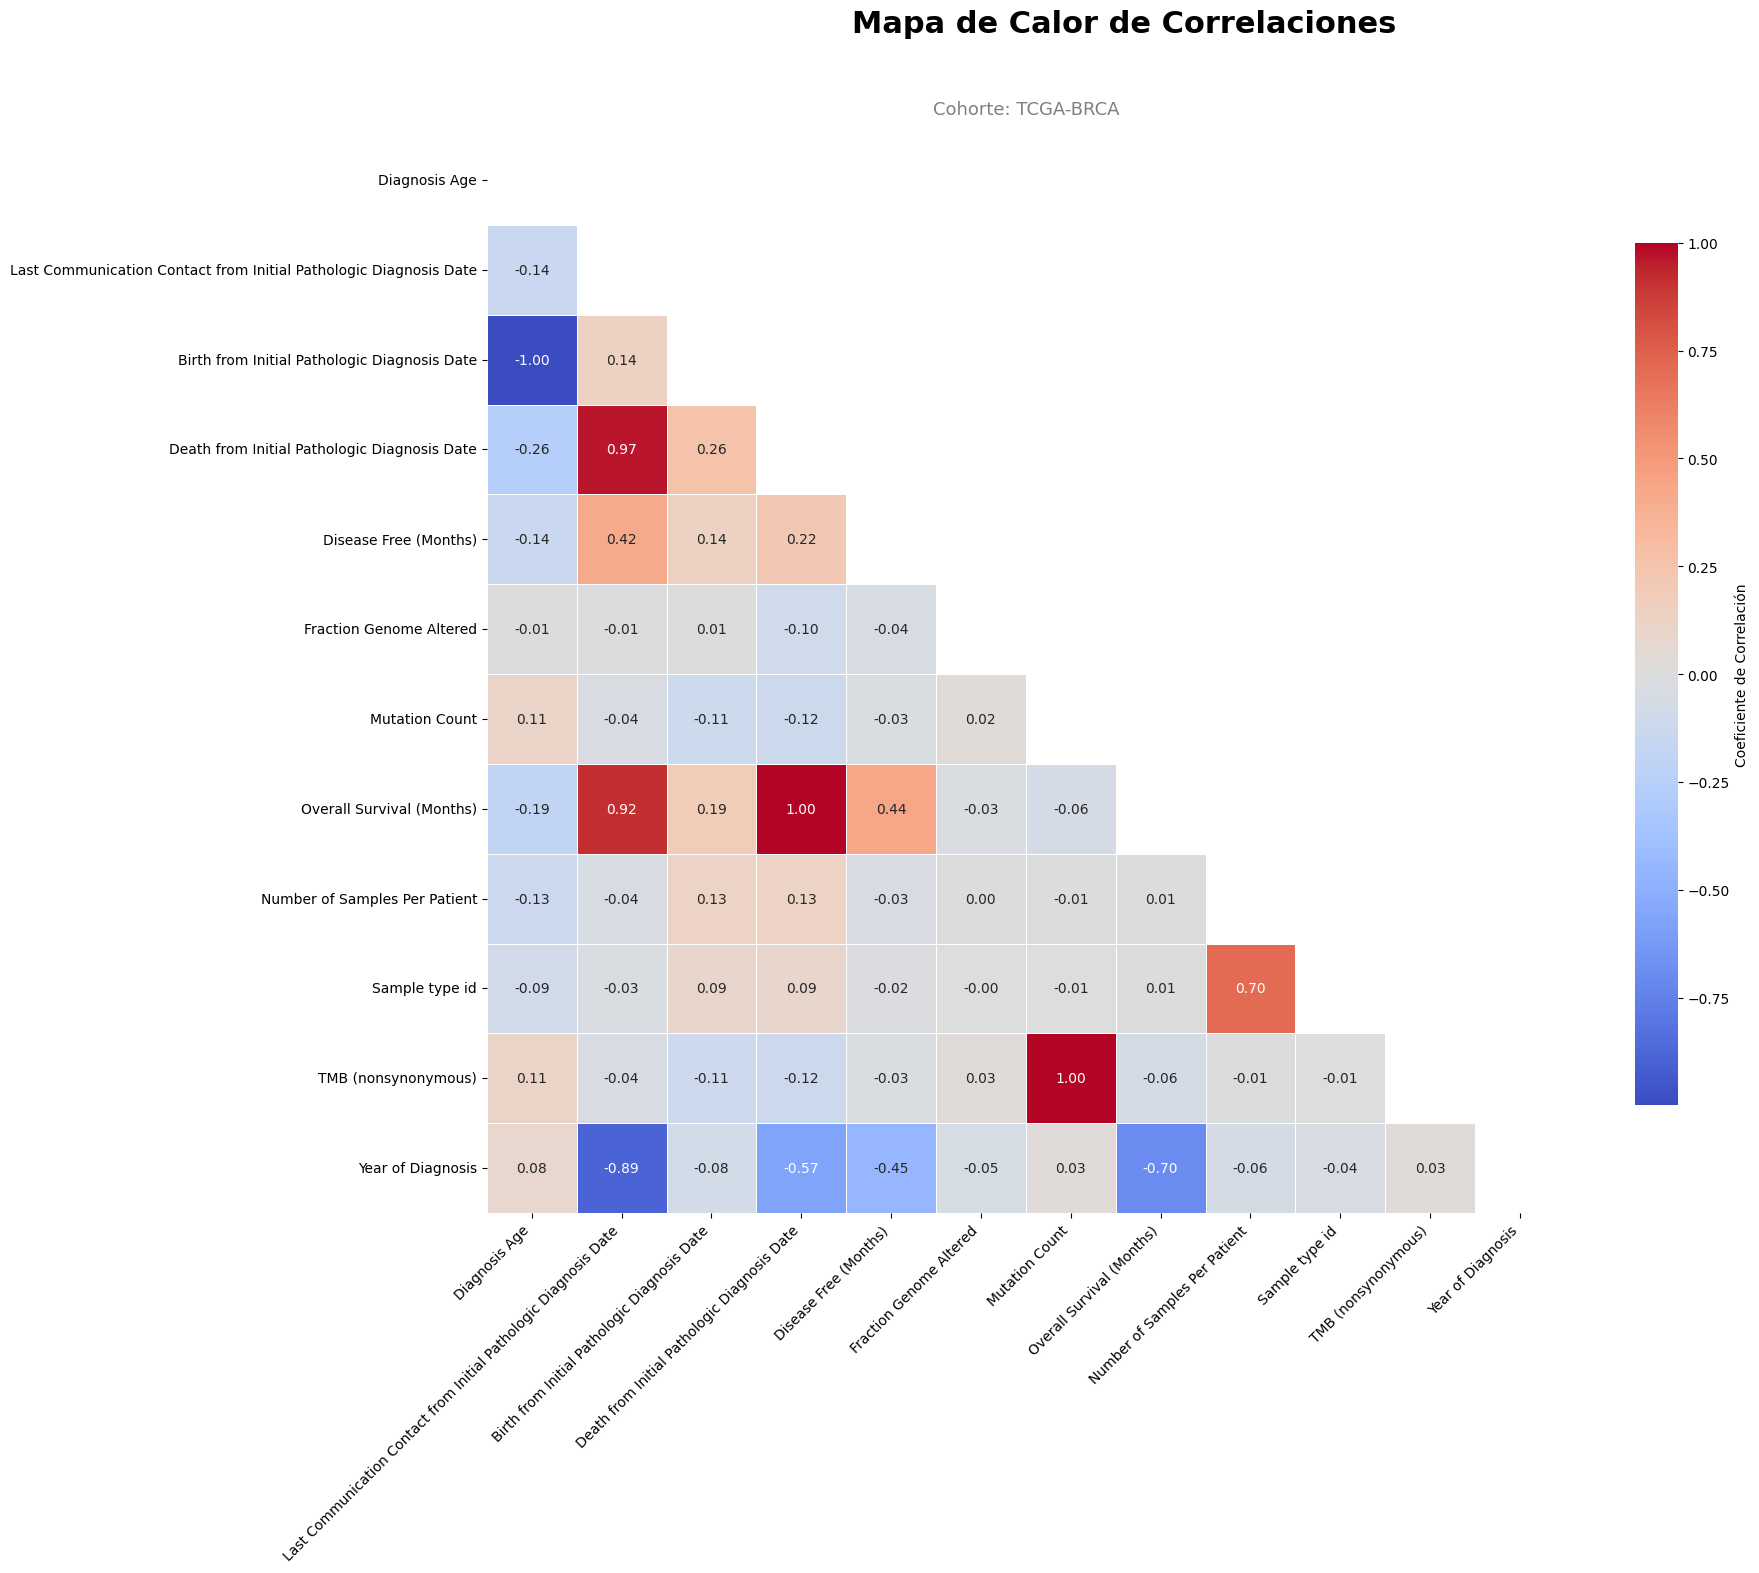


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Resumen de Correlaciones — TCGA-BRCA (Pearson)
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Etiqueta   Par de variables                                                                                                      Corr
  ────────── ────────────────────────────────────────────────────────────────────────────────────────────────────────────────── ───────
  ▲ Top 1    Overall Survival (Months)  ↔  Death from Initial Pathologic Diagnosis Date                                          1.0000
  ▲ Top 2    TMB (nonsynonymous)  ↔  Mutation Count                                                                              0.9999
  ▲ Top 3    Death from Initial Pathologic Diagnosis Date  ↔  Last Communication Contact from Initial Pathologic Diagnosis Date  0.9682
  ▲ 

In [15]:
eda.plot_correlation_heatmap(
    df=tcga_brca,
    dataset_name="TCGA-BRCA",
    output_path=r"..\images\EDA\TCGA-BRCA"
)

## **3.3. Preprocesado de los datos**

Una vez analizados los atributos descriptivos, se prepararon para que nos sean útiles de cara a predecir valores.

In [16]:
# Trabajamos sobre una copia para no modificar el DataFrame del EDA
tcga_prep = tcga_brca.copy()

print(f"Shape inicial: {tcga_prep.shape}")

Shape inicial: (1102, 44)


### **3.3.1. Selección de una muestra primaria por paciente**

TCGA-BRCA contiene algunos pacientes con más de una muestra. Para evitar que un mismo paciente aparezca varias veces en train/test, se priorizan las muestras `Primary Tumor` y se conserva una única fila por `Patient ID`.

In [17]:
n_antes = len(tcga_prep)

if {"Patient ID", "Sample Type"}.issubset(tcga_prep.columns):
    tcga_prep["__sample_priority"] = np.where(tcga_prep["Sample Type"].eq("Primary Tumor"), 0, 1)
    tcga_prep = (
        tcga_prep
        .sort_values(["Patient ID", "__sample_priority"])
        .drop_duplicates(subset=["Patient ID"], keep="first")
        .drop(columns="__sample_priority")
    )

print(f"Registros eliminados por duplicidad muestra-paciente: {n_antes - len(tcga_prep)}")
print(f"Shape resultante: {tcga_prep.shape}")

Registros eliminados por duplicidad muestra-paciente: 7
Shape resultante: (1095, 44)


### **3.3.2. Eliminación de columnas de varianza cero y metadatos irrelevantes**

Se eliminan identificadores únicos, constantes de estudio/proyecto y variables de estructura muestral. Estas columnas no aportan señal clínica generalizable y pueden introducir ruido o sobreajuste.

Se excluyen variables que duplican la variable objetivo, codifican seguimiento posterior al diagnóstico o representan endpoints alternativos:

* `Patient's Vital Status` duplica `Overall Survival Status`.
* `Death from Initial Pathologic Diagnosis Date` y `Last Communication Contact from Initial Pathologic Diagnosis Date` forman parte del cálculo del seguimiento.
* `Birth from Initial Pathologic Diagnosis Date` duplica la edad al diagnóstico.
* `TMB (nonsynonymous)` es redundante con `Mutation Count`.
* `Primary Diagnosis` duplica conceptualmente `Disease Type`.
* `Disease Free (Months)` y `Disease Free Status` corresponden al endpoint de progresión/recaída.

In [18]:
COLS_DROP_METADATA = [
    # Identificadores únicos o casi únicos
    "Patient ID",
    "Sample ID",
    "Other Patient ID",
    "Other Sample ID",

    # Metadatos de estudio/proyecto
    "Study ID",
    "Project Identifier",
    "Project Name",
    "Project State",

    # Constantes o casi constantes en TCGA-BRCA
    "Cancer Type",
    "Cancer Type Detailed",
    "Oncotree Code",
    "Biopsy Site",
    "Patient Primary Tumor Site",
    "Is FFPE",

    # Estructura muestral
    "Number of Samples Per Patient",
    "Sample Type",
    "Sample type id",

    # Variable de codificación/versión, no característica biológica del paciente
    "American Joint Committee on Cancer Publication Version Type",

    # Potencial proxy de calendario/seguimiento, no predictor clínico basal robusto
    "Year of Diagnosis",
]

COLS_REDUNDANTES = [
    "Patient's Vital Status",
    "Death from Initial Pathologic Diagnosis Date",
    "Last Communication Contact from Initial Pathologic Diagnosis Date",
    "Birth from Initial Pathologic Diagnosis Date",
    "Mutation Count",
    "Primary Diagnosis",
]

COLS_LEAKAGE = [
    "Disease Free (Months)",
    "Disease Free Status",
]

COLS_REDUNDANTES_LEAKAGE = COLS_DROP_METADATA + COLS_REDUNDANTES + COLS_LEAKAGE

cols_present = [c for c in COLS_REDUNDANTES_LEAKAGE if c in tcga_prep.columns]
tcga_prep.drop(columns=COLS_REDUNDANTES_LEAKAGE, inplace=True, errors="ignore")

print(f"Columnas eliminadas ({len(cols_present)}): {cols_present}")
print(f"Shape resultante: {tcga_prep.shape}")

Columnas eliminadas (27): ['Patient ID', 'Sample ID', 'Other Patient ID', 'Other Sample ID', 'Study ID', 'Project Identifier', 'Project Name', 'Project State', 'Cancer Type', 'Cancer Type Detailed', 'Oncotree Code', 'Biopsy Site', 'Patient Primary Tumor Site', 'Is FFPE', 'Number of Samples Per Patient', 'Sample Type', 'Sample type id', 'American Joint Committee on Cancer Publication Version Type', 'Year of Diagnosis', "Patient's Vital Status", 'Death from Initial Pathologic Diagnosis Date', 'Last Communication Contact from Initial Pathologic Diagnosis Date', 'Birth from Initial Pathologic Diagnosis Date', 'Mutation Count', 'Primary Diagnosis', 'Disease Free (Months)', 'Disease Free Status']
Shape resultante: (1095, 17)


### **3.3.3. Definición y parsing de las variables objetivo (`duration` y `event`)**

Todos los modelos de supervivencia requieren:

* `duration`: tiempo de seguimiento en meses.
* `event`: indicador binario donde `1`/`True` representa muerte y `0`/`False` representa censura.

En TCGA-BRCA, `Overall Survival Status` está codificada como `0:LIVING` y `1:DECEASED`. Se extrae el primer dígito para obtener el indicador de evento.

In [19]:
tcga_prep["duration"] = tcga_prep["Overall Survival (Months)"].copy()

tcga_prep["event"] = (
    tcga_prep["Overall Survival Status"]
    .astype(str)
    .str.extract(r"^(\d)")[0]
    .astype(float)
)

TARGET_COLS = ["duration", "event"]

# Verificación del objetivo
eda.describe_df(tcga_prep[TARGET_COLS])

Dimensiones del DataFrame: 1095 filas, 2 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,duration,float64,1094,0.09,825,None,40.341896,26.954665,39.072175,-0.229961,14.495729,54.870237,282.687254
1,event,float64,1094,0.09,2,None,0.138026,0.000000,0.345085,0.000000,0.000000,0.000000,1.000000


In [20]:
print(f"Columnas creadas ({len(TARGET_COLS)}) : {TARGET_COLS}")
print(f"Shape resultante    : {tcga_prep.shape}")

print(f"\nDistribución del evento:\n{tcga_prep['event'].value_counts()}")
print(f"Tasa de eventos (censura): {tcga_prep['event'].mean():.2%}")

Columnas creadas (2) : ['duration', 'event']
Shape resultante    : (1095, 19)

Distribución del evento:
event
0.0    943
1.0    151
Name: count, dtype: int64
Tasa de eventos (censura): 13.80%


### **3.3.4. Eliminación de registros con valores nulos en las variables objetivo**

Imputar tiempo de supervivencia o estado vital no es metodológicamente aceptable, porque implicaría inventar cuándo ocurrió el evento o si ocurrió. Se eliminan únicamente los registros sin `duration` o sin `event`.

In [21]:
n_antes = len(tcga_prep)

tcga_prep.dropna(subset=["duration", "event"], inplace=True)

COLS_POST_TARGET = [
    "Overall Survival (Months)",
    "Overall Survival Status",
]

tcga_prep.drop(columns=COLS_POST_TARGET, inplace=True, errors="ignore")

print(f"Columnas eliminadas tras crear target ({len(COLS_POST_TARGET)}): {COLS_POST_TARGET}")
print(f"Shape resultante: {tcga_prep.shape}")
print(f"\nRegistros eliminados: {n_antes - len(tcga_prep)} ({(n_antes - len(tcga_prep)) / n_antes:.2%})")
print(f"Registros restantes : {len(tcga_prep)}")

Columnas eliminadas tras crear target (2): ['Overall Survival (Months)', 'Overall Survival Status']
Shape resultante: (1094, 17)

Registros eliminados: 1 (0.09%)
Registros restantes : 1094


### **3.3.5. Tratamiento de tiempos de supervivencia en cero**

Los tiempos `T = 0` pueden causar problemas numéricos en modelos basados en Cox y en algunos algoritmos de supervivencia. Se corrigen a un valor mínimo positivo (`0.001` meses) sin eliminar registros.

In [22]:
EPSILON = 0.001

n_ceros = (tcga_prep["duration"] == 0).sum()
tcga_prep["duration"] = tcga_prep["duration"].clip(lower=EPSILON)

print(f"Registros con T=0 corregidos : {n_ceros}")
print(f"Tiempo mínimo tras corrección: {tcga_prep['duration'].min():.4f} meses")
print(f"Tiempo máximo                : {tcga_prep['duration'].max():.2f} meses")

Registros con T=0 corregidos : 20
Tiempo mínimo tras corrección: 0.0010 meses
Tiempo máximo                : 282.69 meses


### **3.3.6. Selección del subconjunto de covariables para el modelado**

Una vez eliminado el objetivo original y las columnas con fuga de información, las covariables restantes quedan como candidatas para Cox, RSF y DeepSurv.

In [23]:
# Separar covariables de las variables objetivo
FEATURE_COLS  = [c for c in tcga_prep.columns if c not in TARGET_COLS]

print(f"Covariables candidatas ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Shape resultante      : {tcga_prep.shape}")

Covariables candidatas (15): ['Diagnosis Age', 'Disease Type', 'Ethnicity Category', 'Fraction Genome Altered', 'ICD-10 Classification', 'Morphology', 'AJCC Pathologic M-Stage', 'AJCC Pathologic N-Stage', 'AJCC Pathologic Stage', 'AJCC Pathologic T-Stage', 'Prior Malignancy', 'Prior Treatment', 'Race Category', 'Sex', 'TMB (nonsynonymous)']
Shape resultante      : (1094, 17)


### **3.3.7. División estratificada en conjuntos train/test**

Se usa una partición **80/20** con estratificación por el indicador de evento. La estratificación es crítica en análisis de supervivencia porque una partición aleatoria simple podría generar un conjunto de test con una tasa de censura muy distinta a la del train, haciendo que las métricas de evaluación (C-index, Brier Score) sean poco representativas del rendimiento real. El `random_state` fijo garantiza la reproducibilidad de todos los experimentos del TFM.

In [24]:
X = tcga_prep[FEATURE_COLS].copy()
y_duration = tcga_prep["duration"].astype(float).values
y_event = tcga_prep["event"].astype(int).values

X_train, X_test, dur_train, dur_test, evt_train, evt_test = train_test_split(
    X,
    y_duration,
    y_event,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify     = y_event.astype(int)
 )

print(f"Train: {len(X_train)} registros | Tasa de eventos: {evt_train.mean():.2%}")
print(f"Test : {len(X_test)} registros | Tasa de eventos: {evt_test.mean():.2%}")

Train: 875 registros | Tasa de eventos: 13.83%
Test : 219 registros | Tasa de eventos: 13.70%


### **3.3.8. Imputación de valores nulos en covariables**

La estrategia reproduce el enfoque de METABRIC:

* Variables numéricas → mediana calculada solo en train.
* Variables categóricas → categoría explícita `"Unknown"`.

Después de imputar las categóricas, se convierten a string para evitar errores de `OneHotEncoder` cuando una columna mezcla booleanos (`True`/`False`) con `"Unknown"`.

In [25]:
NUM_COLS = X_train.select_dtypes(include="number").columns.tolist()
CAT_COLS = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Variables numéricas ({len(NUM_COLS)}): {NUM_COLS}")
print(f"\nVariables categóricas ({len(CAT_COLS)}): {CAT_COLS}")

Variables numéricas (3): ['Diagnosis Age', 'Fraction Genome Altered', 'TMB (nonsynonymous)']

Variables categóricas (12): ['Disease Type', 'Ethnicity Category', 'ICD-10 Classification', 'Morphology', 'AJCC Pathologic M-Stage', 'AJCC Pathologic N-Stage', 'AJCC Pathologic Stage', 'AJCC Pathologic T-Stage', 'Prior Malignancy', 'Prior Treatment', 'Race Category', 'Sex']


In [26]:
imputer_num = SimpleImputer(strategy="median")
imputer_cat = SimpleImputer(strategy="constant", fill_value="Unknown")

X_train[NUM_COLS] = imputer_num.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = imputer_num.transform(X_test[NUM_COLS])

X_train[CAT_COLS] = imputer_cat.fit_transform(X_train[CAT_COLS])
X_test[CAT_COLS]  = imputer_cat.transform(X_test[CAT_COLS])

print("Nulos tras imputación:")
print(f"  X_train: {X_train.isna().sum().sum()}")
print(f"  X_test : {X_test.isna().sum().sum()}")

Nulos tras imputación:
  X_train: 0
  X_test : 0


### **3.3.9. Tratamiento de outliers en variables numéricas continuas**

Se aplica winsorización empírica al percentil 1–99, calculando los umbrales únicamente en train y aplicándolos a train/test. Esta decisión reduce el impacto de valores extremos en Cox y DeepSurv sin eliminar observaciones.

In [27]:
COLS_WINSORIZE = [
    "Diagnosis Age",
    "Fraction Genome Altered",
    "TMB (nonsynonymous)",
]

winsor_limits = {}

for col in COLS_WINSORIZE:
    if col in X_train.columns:
        p01 = np.percentile(X_train[col].astype(float), 1)
        p99 = np.percentile(X_train[col].astype(float), 99)
        winsor_limits[col] = (p01, p99)

        X_train[col] = X_train[col].clip(lower=p01, upper=p99)
        X_test[col] = X_test[col].clip(lower=p01, upper=p99)

        print(f"{col:<30} -> clipped a [{p01:.4f}, {p99:.4f}]")

Diagnosis Age                  -> clipped a [30.7400, 89.0000]
Fraction Genome Altered        -> clipped a [0.0001, 0.9024]
TMB (nonsynonymous)            -> clipped a [0.2580, 23.6627]


### **3.3.10. Codificación de variables categóricas**

Cox, RSF y DeepSurv requieren entradas numéricas. Se usa One-Hot Encoding con:

* `drop='first'` para reducir multicolinealidad perfecta.
* `handle_unknown='ignore'` para tolerar categorías nuevas en test.

> El encoder se ajusta solo sobre train.

In [28]:
encoder = OneHotEncoder(
    drop           = 'first',
    sparse_output  = False,
    handle_unknown = 'ignore',
    dtype          = float
)

# Forzar todas las columnas categóricas a string para evitar el conflicto bool vs str
X_train[CAT_COLS] = X_train[CAT_COLS].astype(str)
X_test[CAT_COLS] = X_test[CAT_COLS].astype(str)

# Ahora el encoder funcionará sin problemas
ohe_train = encoder.fit_transform(X_train[CAT_COLS])
ohe_test = encoder.transform(X_test[CAT_COLS])

# Nombres de las nuevas columnas
ohe_feature_names = encoder.get_feature_names_out(CAT_COLS).tolist()

# Construir DataFrames con columnas OHE
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_feature_names, index=X_train.index)
ohe_test_df = pd.DataFrame(ohe_test, columns=ohe_feature_names, index=X_test.index)

# Reemplazar categóricas originales por OHE
X_train = pd.concat([X_train.drop(columns=CAT_COLS), ohe_train_df], axis=1)
X_test = pd.concat([X_test.drop(columns=CAT_COLS), ohe_test_df], axis=1)


print(f"Shape X_train tras OHE: {X_train.shape}")
print(f"Shape X_test tras OHE : {X_test.shape}")
print(f"Total covariables finales: {X_train.shape[1]}")

Shape X_train tras OHE: (875, 88)
Shape X_test tras OHE : (219, 88)
Total covariables finales: 88


### **3.3.11. Escalado de variables numéricas**

Se aplica `StandardScaler` solo sobre las variables numéricas originales. Aunque RSF no requiere escalado, mantener un pipeline homogéneo facilita la comparación con Cox y DeepSurv.

In [29]:
scaler = StandardScaler()

X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = scaler.transform(X_test[NUM_COLS])

print(f"Variables escaladas ({len(NUM_COLS)}): {NUM_COLS}")
eda.describe_df(X_train[NUM_COLS])[['Column', 'mean', 'std']]

Variables escaladas (3): ['Diagnosis Age', 'Fraction Genome Altered', 'TMB (nonsynonymous)']
Dimensiones del DataFrame: 875 filas, 3 columnas



,Column,mean,std
0,Diagnosis Age,2.070725e-16,1.000572
1,Fraction Genome Altered,8.120488e-17,1.000572
2,TMB (nonsynonymous),-1.015061e-18,1.000572


### **3.3.12. Creación del `structured array` de scikit-survival**

`scikit-survival` espera un array estructurado con dos campos:

* `event`: booleano.
* `time`: tiempo de seguimiento.

Si `scikit-survival` está instalado, se usa `Surv.from_arrays`. Si no lo está, se crea un array equivalente con `numpy`.

In [30]:
y_train = Surv.from_arrays(
    event = evt_train.astype(bool),
    time  = dur_train.astype(float)
)

y_test = Surv.from_arrays(
    event = evt_test.astype(bool),
    time  = dur_test.astype(float)
)

# Arrays en formato numpy para DeepSurv / lifelines
X_train_np = X_train.values.astype(float)
X_test_np  = X_test.values.astype(float)

print(f"y_train dtype : {y_train.dtype}  | shape: {y_train.shape}")
print(f"y_test  dtype : {y_test.dtype}   | shape: {y_test.shape}")
print(f"X_train_np    : {X_train_np.shape}")
print(f"X_test_np     : {X_test_np.shape}")

y_train dtype : [('event', '?'), ('time', '<f8')]  | shape: (875,)
y_test  dtype : [('event', '?'), ('time', '<f8')]   | shape: (219,)
X_train_np    : (875, 88)
X_test_np     : (219, 88)


### **3.3.13. Objetos finales para Cox, RSF y DeepSurv**

Se crean vistas específicas para cada familia de modelos:

* `cox_train_df`, `cox_test_df`: formato cómodo para `lifelines.CoxPHFitter`.
* `X_train`, `X_test`, `y_train`, `y_test`: formato para `scikit-survival`.
* `X_train_deepsurv`, `X_test_deepsurv`, `dur_*_deepsurv`, `evt_*_deepsurv`: arrays `float32` para `pycox`.

In [31]:
SAVE_DIR = '../data/processed/tcga_brca'
os.makedirs(SAVE_DIR, exist_ok=True)

tcga_prep.to_csv(f'{SAVE_DIR}/brca_tcga_preprocessed.csv', index=False)

# X — covariables
np.save(f'{SAVE_DIR}/X_train_np.npy', X_train_np)
np.save(f'{SAVE_DIR}/X_test_np.npy',  X_test_np)

# y — tiempos y eventos por separado
np.save(f'{SAVE_DIR}/dur_train.npy',  dur_train)
np.save(f'{SAVE_DIR}/dur_test.npy',   dur_test)
np.save(f'{SAVE_DIR}/evt_train.npy',  evt_train)
np.save(f'{SAVE_DIR}/evt_test.npy',   evt_test)

# y — structured arrays (scikit-survival no acepta arrays separados)
joblib.dump(y_train, f'{SAVE_DIR}/y_train.pkl')
joblib.dump(y_test,  f'{SAVE_DIR}/y_test.pkl')

# X — DataFrame con nombres de columnas (lifelines lo requiere)
X_train.to_parquet(f'{SAVE_DIR}/X_train_df.parquet')
X_test.to_parquet(f'{SAVE_DIR}/X_test_df.parquet')

print("✓ Datos guardados en:", SAVE_DIR)

✓ Datos guardados en: ../data/processed/tcga_brca
